# Introduction

The Flight Data 2024 dataset from Kaggle provides a comprehensive snapshot of global air travel during 2024. It includes detailed information about airlines, routes, schedules, and flight delays. By analyzing this dataset, we aim to uncover patterns in flight operations, explore factors contributing to delays, and compare airline performance. This analysis will help visualize travel trends and provide data-driven insights into the efficiency of air transportation in 2024.

# Import Necessary Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# math functions like sqrt, sin, cos....etc
import math as m 
# work with dates and times, for example years, months, days, hours, minutes, and seconds
import datetime as dt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Read The Dataset 

In [2]:
flt = pd.read_csv("/kaggle/input/flight-delay-and-cancellation-data-1-million-2024/flight_data_2024.csv")
flt

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2024,2,29,4,2/29/2024,SJU,"San Juan, PR",Puerto Rico,1447.0,24.0,1511.0,1640.0,7.0,0,149.0,1045,0,0
1048571,2024,2,29,4,2/29/2024,PHX,"Phoenix, AZ",Arizona,59.0,12.0,111.0,647.0,3.0,0,216.0,1972,0,105
1048572,2024,2,29,4,2/29/2024,JAX,"Jacksonville, FL",Florida,2014.0,20.0,2034.0,2128.0,10.0,0,54.0,328,0,0
1048573,2024,2,29,4,2/29/2024,CLT,"Charlotte, NC",North Carolina,1104.0,12.0,1116.0,1210.0,7.0,0,114.0,808,0,70


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the structure, quality, and key patterns of the dataset before building any model or drawing conclusions. Here, we explore the Flight Data 2024 dataset to identify trends, missing values, and relationships between different flight-related features.

In [3]:
# display the first 5 rows in the dataset 
flt.head()

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0


In [4]:
# show the describe() in dataset 
flt.describe()

,year,month,day_of_month,day_of_week,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
count,1048575.0,1.048575e+06,1.048575e+06,1.048575e+06,1.026022e+06,1.025450e+06,1.025450e+06,1.024898e+06,1.024898e+06,1.048575e+06,1.022824e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2024.0,1.478081e+00,1.530512e+01,3.893483e+00,1.325074e+03,1.825012e+01,1.349996e+03,1.476156e+03,8.082517e+00,2.222635e-02,1.162270e+02,8.345389e+02,1.194321e+00,5.326660e+00
std,0.0,4.995196e-01,8.585503e+00,2.010038e+00,4.972990e+02,1.044025e+01,4.980426e+02,5.198682e+02,6.512591e+00,1.474190e-01,7.091204e+01,5.923104e+02,2.005819e+01,2.975676e+01
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,8.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00
25%,2024.0,1.000000e+00,8.000000e+00,2.000000e+00,9.110000e+02,1.200000e+01,9.290000e+02,1.058000e+03,4.000000e+00,0.000000e+00,6.400000e+01,4.020000e+02,0.000000e+00,0.000000e+00
50%,2024.0,1.000000e+00,1.500000e+01,4.000000e+00,1.323000e+03,1.500000e+01,1.337000e+03,1.510000e+03,6.000000e+00,0.000000e+00,1.000000e+02,6.920000e+02,0.000000e+00,0.000000e+00
75%,2024.0,2.000000e+00,2.300000e+01,6.000000e+00,1.736000e+03,2.100000e+01,1.750000e+03,1.914000e+03,9.000000e+00,0.000000e+00,1.470000e+02,1.069000e+03,0.000000e+00,0.000000e+00
max,2024.0,2.000000e+00,3.100000e+01,7.000000e+00,2.400000e+03,2.130000e+02,2.400000e+03,2.400000e+03,4.440000e+02,1.000000e+00,7.230000e+02,5.095000e+03,1.804000e+03,2.100000e+03


In [5]:
# display the info (information) dataset
flt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   year                 1048575 non-null  int64  
 1   month                1048575 non-null  int64  
 2   day_of_month         1048575 non-null  int64  
 3   day_of_week          1048575 non-null  int64  
 4   fl_date              1048575 non-null  object 
 5   origin               1048575 non-null  object 
 6   origin_city_name     1048575 non-null  object 
 7   origin_state_nm      1048575 non-null  object 
 8   dep_time             1026022 non-null  float64
 9   taxi_out             1025450 non-null  float64
 10  wheels_off           1025450 non-null  float64
 11  wheels_on            1024898 non-null  float64
 12  taxi_in              1024898 non-null  float64
 13  cancelled            1048575 non-null  int64  
 14  air_time             1022824 non-null  float64
 15

In [6]:
# how much this dataset rows and columns 
var  = pd.DataFrame([flt.shape], columns = ["Rows", "Columns"])
var

,Rows,Columns
0,1048575,18


In [7]:
var = pd.DataFrame({
    "Column Name": flt.columns,
    "Data Type": flt.dtypes.values
})
var

,Column Name,Data Type
0,year,int64
1,month,int64
2,day_of_month,int64
3,day_of_week,int64
4,fl_date,object
5,origin,object
6,origin_city_name,object
7,origin_state_nm,object
8,dep_time,float64
9,taxi_out,float64


# Checking if there is any Duplicated values present in the Dataset

In [8]:
flt.duplicated().sum()


7401

# Checking if there is any NaN values present in the Dataset

In [9]:
flt.isnull().sum()

year                       0
month                      0
day_of_month               0
day_of_week                0
fl_date                    0
origin                     0
origin_city_name           0
origin_state_nm            0
dep_time               22553
taxi_out               23125
wheels_off             23125
wheels_on              23677
taxi_in                23677
cancelled                  0
air_time               25751
distance                   0
weather_delay              0
late_aircraft_delay        0
dtype: int64

# Pie Chart In The Dataset

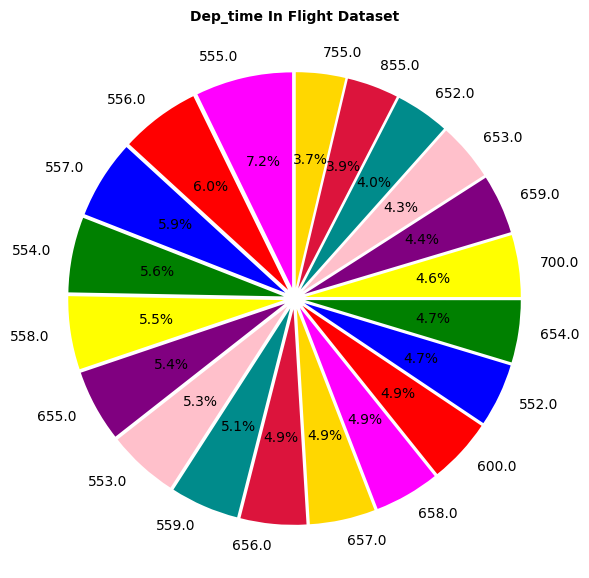

In [10]:
top_1 = flt["dep_time"].value_counts().head(20)
colors =["Magenta","red","blue","green","yellow","purple","pink","darkcyan","crimson", "gold"]
explode = [0.05]* len(top_1)

plt.figure(figsize=(10, 7))
plt.pie(top_1.values,
       labels = top_1.index.astype(str),
       colors = colors,
       autopct = "%1.1f%%",
       startangle=90,
       explode = explode)

plt.title("Dep_time In Flight Dataset",fontsize = 10, fontweight = "bold")
plt.show()

# Sub_plot in Dataset

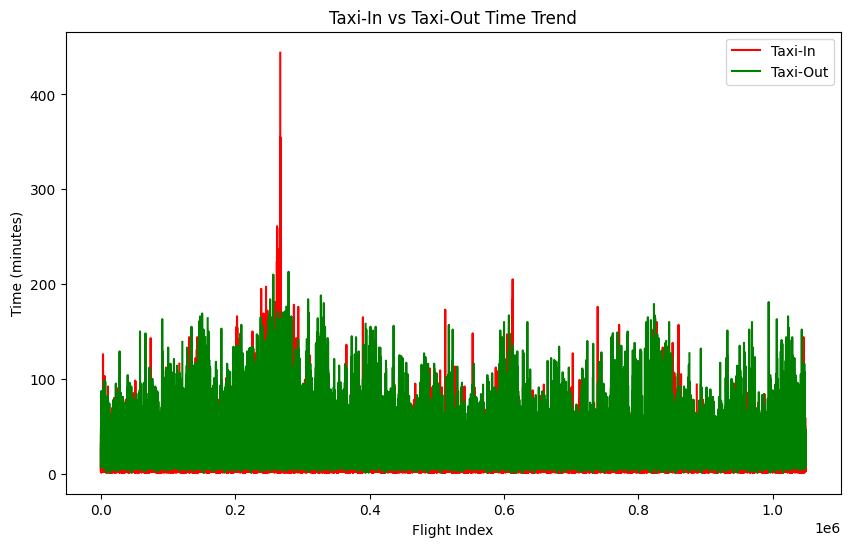

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(flt.index, flt['taxi_in'], color='red', label='Taxi-In')
ax.plot(flt.index, flt['taxi_out'], color='green', label='Taxi-Out')

ax.set_title("Taxi-In vs Taxi-Out Time Trend")
ax.set_xlabel("Flight Index")
ax.set_ylabel("Time (minutes)")
ax.legend()

plt.show()


# Scatter Plot In Dataset 

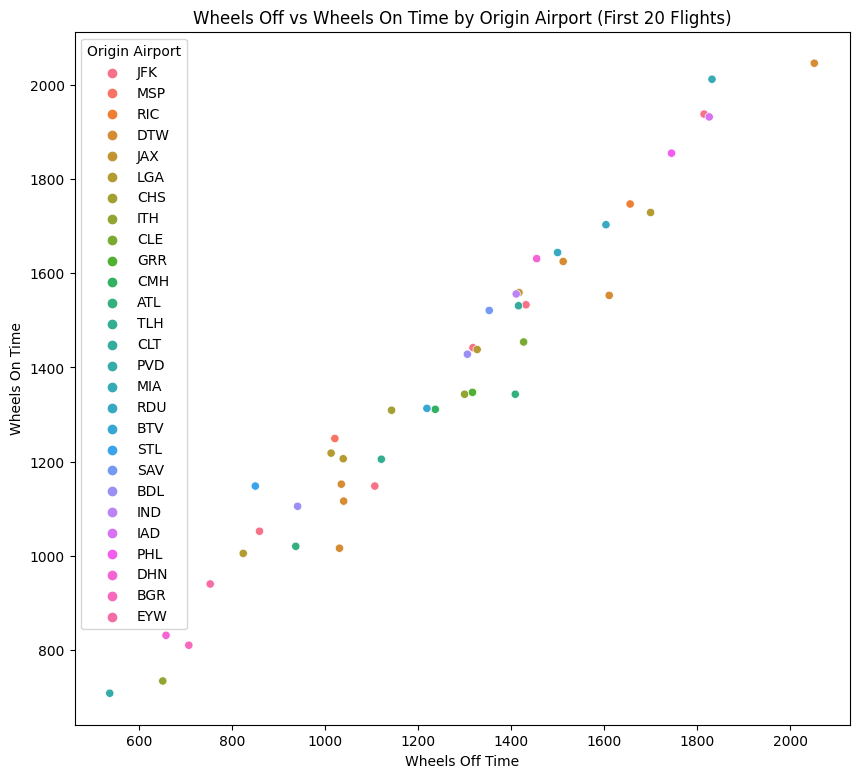

In [12]:
plt.figure(figsize=(10,9))
sns.scatterplot(
    data=flt.head(45),   # show just first 20 rows
    x='wheels_off',
    y='wheels_on',
    hue='origin'
)
plt.title("Wheels Off vs Wheels On Time by Origin Airport (First 20 Flights)")
plt.xlabel("Wheels Off Time")
plt.ylabel("Wheels On Time")
plt.legend(title='Origin Airport')
plt.show()


# Pairplot in Dataset

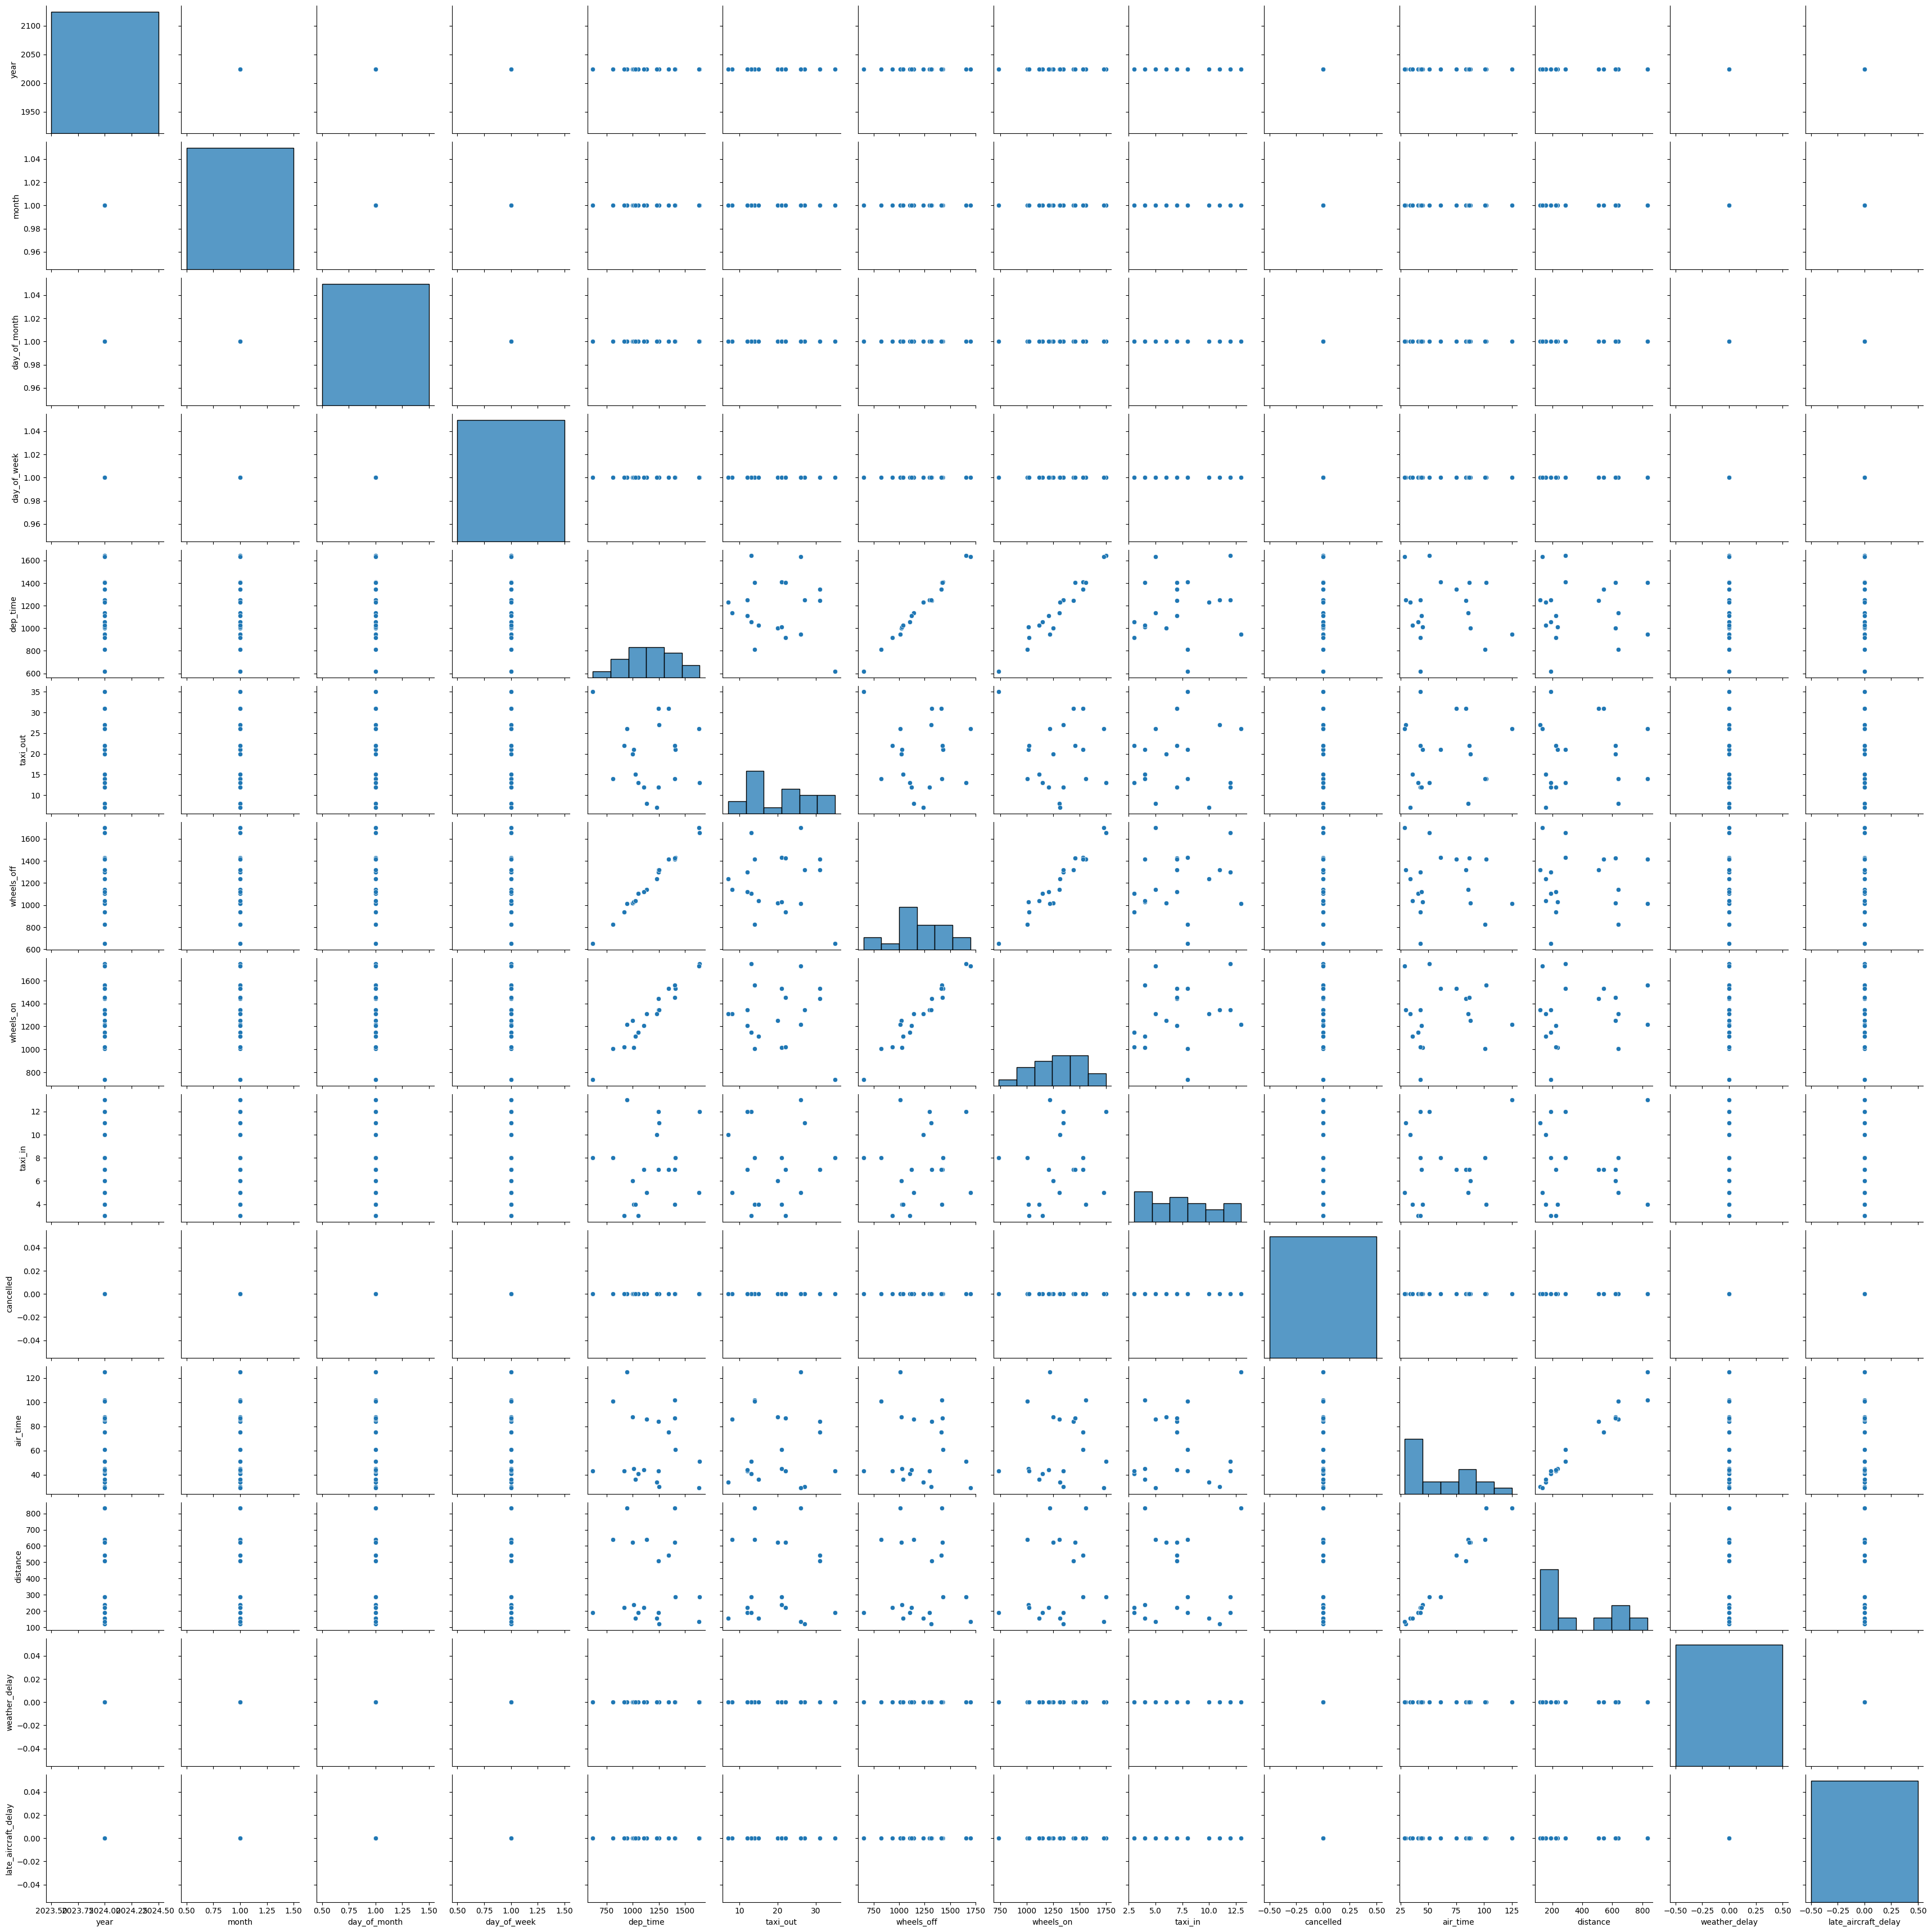

In [13]:
sns.pairplot(flt.head(20))
plt.show()


# Line Plot In Dataset

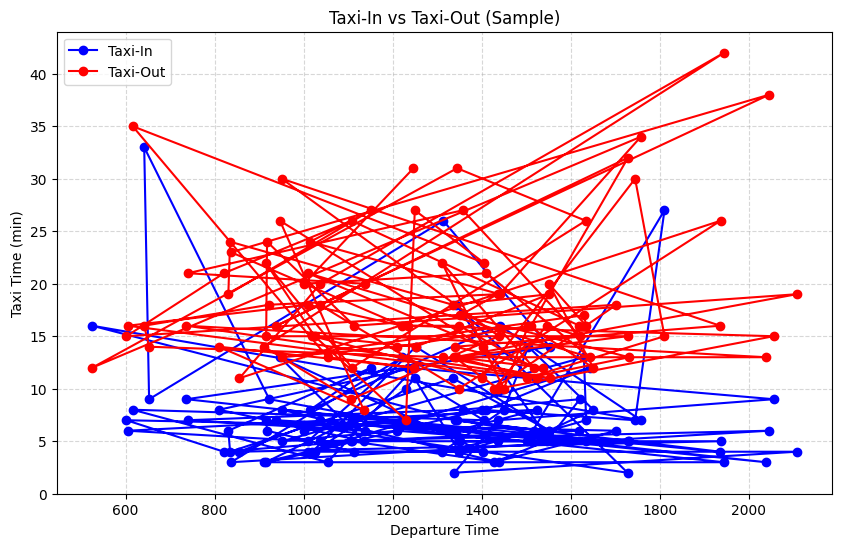

In [14]:
plt.figure(figsize=(10,6))
sample = flt.head(100)  # display just first 100 rows
plt.plot(sample['dep_time'], sample['taxi_in'], 'bo-', label='Taxi-In')
plt.plot(sample['dep_time'], sample['taxi_out'], 'ro-', label='Taxi-Out')
plt.title("Taxi-In vs Taxi-Out (Sample)")
plt.xlabel("Departure Time")
plt.ylabel("Taxi Time (min)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# BarPlot In Dataset

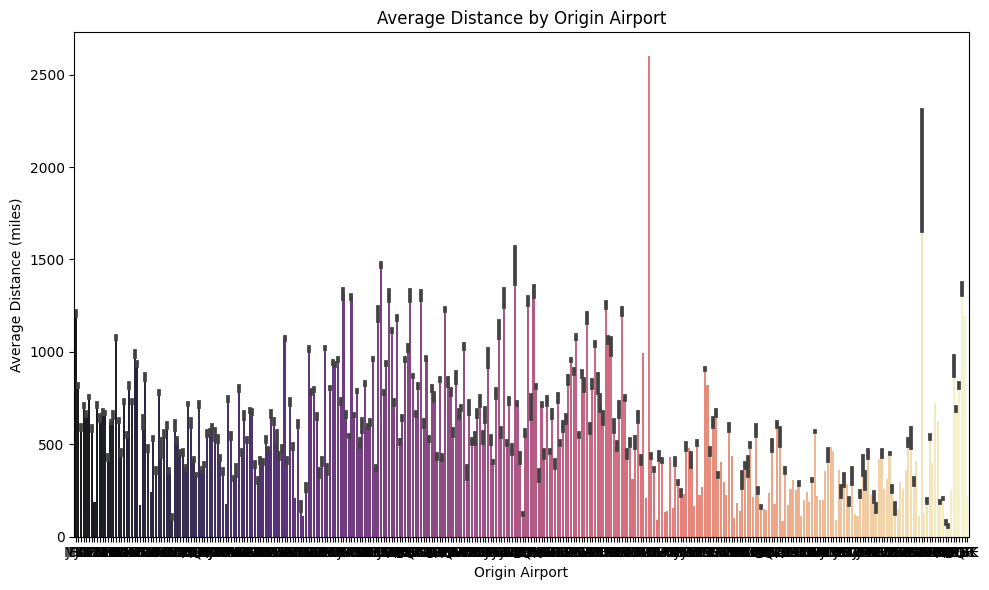

In [15]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=flt,
    x='origin',
    y='distance',
    palette='magma',
    alpha=0.9
)
plt.title("Average Distance by Origin Airport")
plt.xlabel("Origin Airport")
plt.ylabel("Average Distance (miles)")
plt.tight_layout()
plt.show()


# Violinplot in Dataset

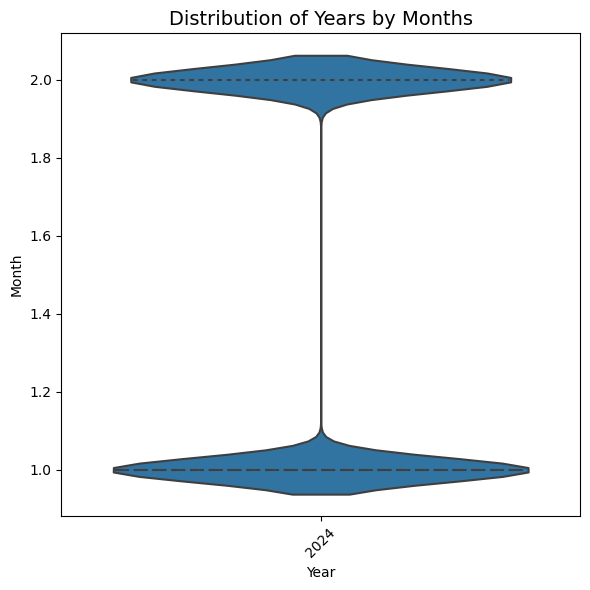

In [16]:
plt.figure(figsize=(6,6))
sns.violinplot(data=flt, x="year", y="month", inner="quartile", scale="width")

plt.title("Distribution of Years by Months", fontsize=14)
plt.xticks(rotation=45)
plt.ylabel("Month")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# Histogram In Dataset

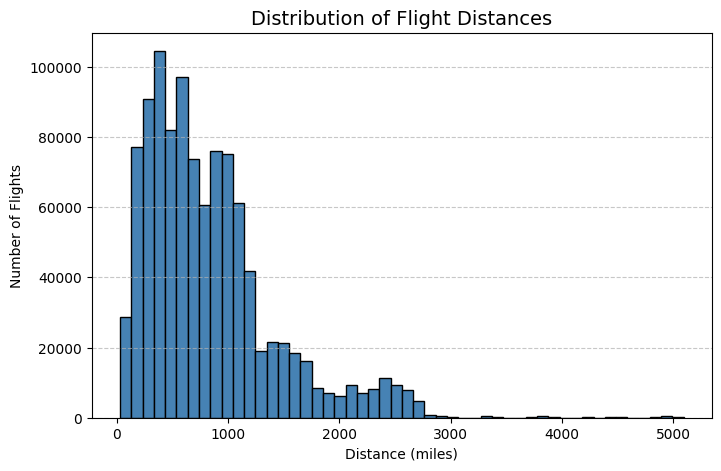

In [17]:
plt.figure(figsize=(8,5))
plt.hist(flt["distance"], bins=50, color='steelblue', edgecolor='black')

plt.title("Distribution of Flight Distances", fontsize=14)
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Heatmap In Dataset

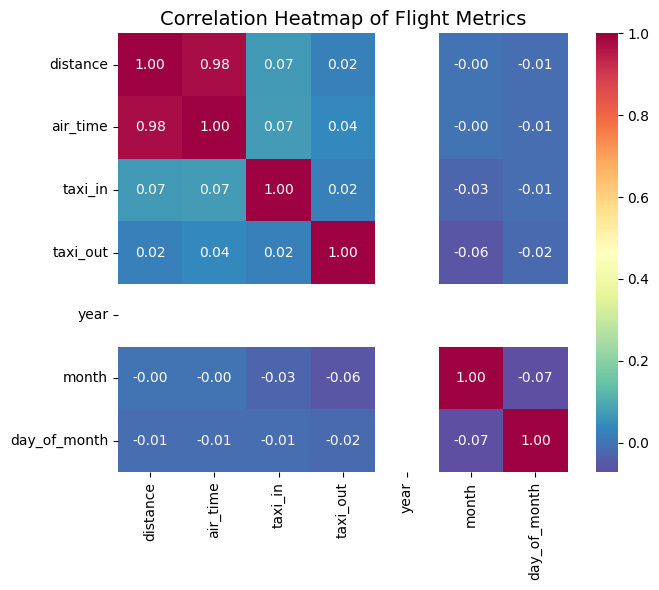

In [18]:
corr = flt[['distance', 'air_time', 'taxi_in', 'taxi_out', "year", "month", "day_of_month"]].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="Spectral_r", fmt=".2f")
plt.title("Correlation Heatmap of Flight Metrics", fontsize=14)
plt.tight_layout()
plt.show()


# Conclusion

The relationships between important flight variables like distance, air time, and origin details can be seen in the correlation heatmap. Stronger correlations with origin-related attributes suggest that these are categorical or location-based factors with limited numerical influence, while the positive correlation between distance and air time indicates that longer flights naturally take longer to complete. Overall, this analysis reveals patterns in flight performance and operational efficiency by highlighting the close connection between flight duration and distance.

# Thank You For Everyone 👍